In [1]:
!pip install yfinance
!pip install textblob transformers nltk
!pip install seaborn numpy pandas matplotlib numpy keras sklearn

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-4.0.2-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached peewee-4.0.2


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\atul.singh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached nltk-3.9.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\atul.singh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\atul.singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\atul.singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\atul.singh\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
# Fetch stock data using Yahoo Finance (Apple as an example)
stock_symbol = "AAPL"
start_date = "2015-01-01"
end_date = "2023-01-01"

stock_data = yf.download(stock_symbol, start=start_date, end=end_date)
# print(stock_data.head())
stock_data['Date'] = stock_data.index
# stock_data[].head()
stock_data = stock_data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Open,High,Low,Close,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,2015-01-02,24.671151,24.682226,23.776353,24.214893,212818400
2015-01-05,2015-01-05,23.984547,24.064282,23.346673,23.532719,257142000
2015-01-06,2015-01-06,23.596956,23.794077,23.173920,23.534941,263188400
2015-01-07,2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600
2015-01-08,2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000


In [18]:
# Example news headlines related to the stock
news_headlines = [
    "Apple shares hit all-time high",
    "Apple reports better-than-expected earnings",
    "Apple announces new product launch",
    "Apple stocks fall due to market conditions",
    "Apple faces supply chain issues"
]

# Sentiment analysis using TextBlob (could be replaced with VADER or any other library)
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Calculate sentiment for each headline (assuming each headline corresponds to a stock entry)
news_sentiments = [get_sentiment(headline) for headline in news_headlines]

# Add a 'Sentiment' column to the stock data (use the sentiment value from the news data)
# For demonstration, just assigning random sentiment scores for each date (real-world implementation would map sentiment to dates)
stock_data['Sentiment'] = np.random.choice(news_sentiments, size=len(stock_data))

stock_data.head()

Price,Date,Open,High,Low,Close,Volume,Sentiment
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2015-01-02,2015-01-02,24.671151,24.682226,23.776353,24.214893,212818400,0.160000
2015-01-05,2015-01-05,23.984547,24.064282,23.346673,23.532719,257142000,0.136364
2015-01-06,2015-01-06,23.596956,23.794077,23.173920,23.534941,263188400,0.160000
2015-01-07,2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600,0.136364
2015-01-08,2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000,0.000000


In [19]:
# Scaling the stock prices (for model input)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_stock_data = scaler.fit_transform(stock_data[['Close']])
# Feature Engineering: Combining stock data and sentiment
X = []
y = []

# Time steps to predict future stock price using the past 60 days
time_steps = 60

# Prepare the data in sequences of 60 days with both stock price and sentiment
for i in range(time_steps, len(scaled_stock_data)):
    X.append(np.column_stack([scaled_stock_data[i-time_steps:i, 0], stock_data['Sentiment'][i-time_steps:i]]))  # Combine sentiment with stock data
    y.append(scaled_stock_data[i, 0])

X = np.array(X)
y = np.array(y)
#
# Reshaping X to fit LSTM input (samples, timesteps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 2))  # 2 because we have two features: stock price and sentiment

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [20]:
# Building the LSTM model
model = Sequential()

# Adding LSTM layers with Dropout to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))  # input_shape should match (timesteps, features)
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Adding the output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


C:\Users\atul.singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0080 - val_loss: 0.0052
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 9.9861e-04 - val_loss: 0.0015
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 9.5667e-04 - val_loss: 0.0015
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0010 - val_loss: 0.0026
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 9.3354e-04 - val_loss: 0.0018
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 8.5014e-04 - val_loss: 0.0018
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 8.9819e-04 - val_loss: 0.0050
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 8.5035e-04 - val_loss: 0.0015


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


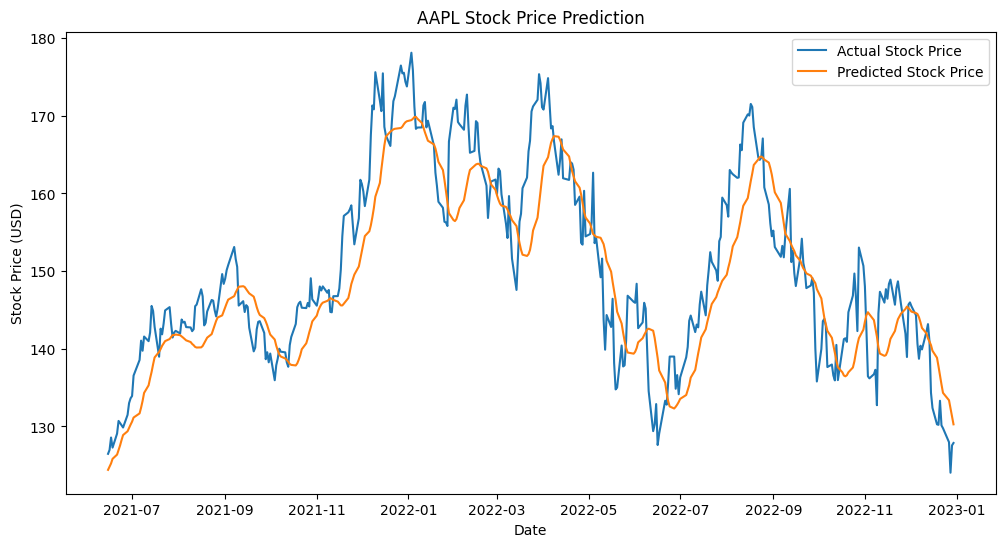

In [21]:
# Predict stock prices using the model
predicted_stock_price = model.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):],
         scaler.inverse_transform(y_test.reshape(-1, 1)), label="Actual Stock Price")
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], predicted_stock_price, label="Predicted Stock Price")
plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

In [22]:
# Calculate model performance (e.g., RMSE)
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(scaler.inverse_transform(y_test.reshape(-1, 1)), predicted_stock_price))
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 6.041644822020044


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


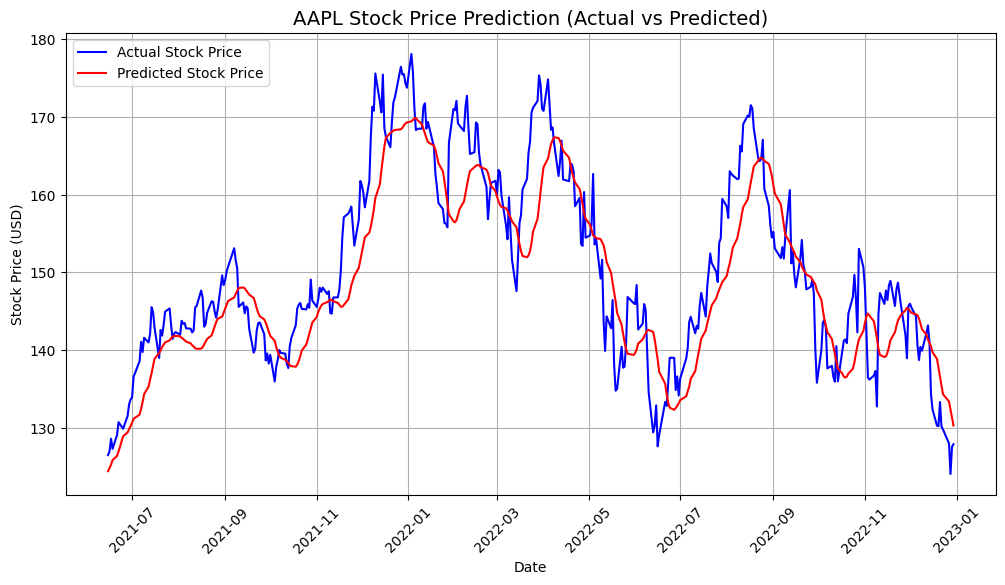

In [23]:
# Plotting Actual vs Predicted Stock Price
plt.figure(figsize=(12, 6))

# Inverse scale to get actual values
actual_stock_price = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_stock_price = scaler.inverse_transform(model.predict(X_test))

# Plot
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], actual_stock_price, label="Actual Stock Price", color='blue')
plt.plot(stock_data['Date'][len(stock_data) - len(predicted_stock_price):], predicted_stock_price, label="Predicted Stock Price", color='red')

# Title and labels
plt.title(f'{stock_symbol} Stock Price Prediction (Actual vs Predicted)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

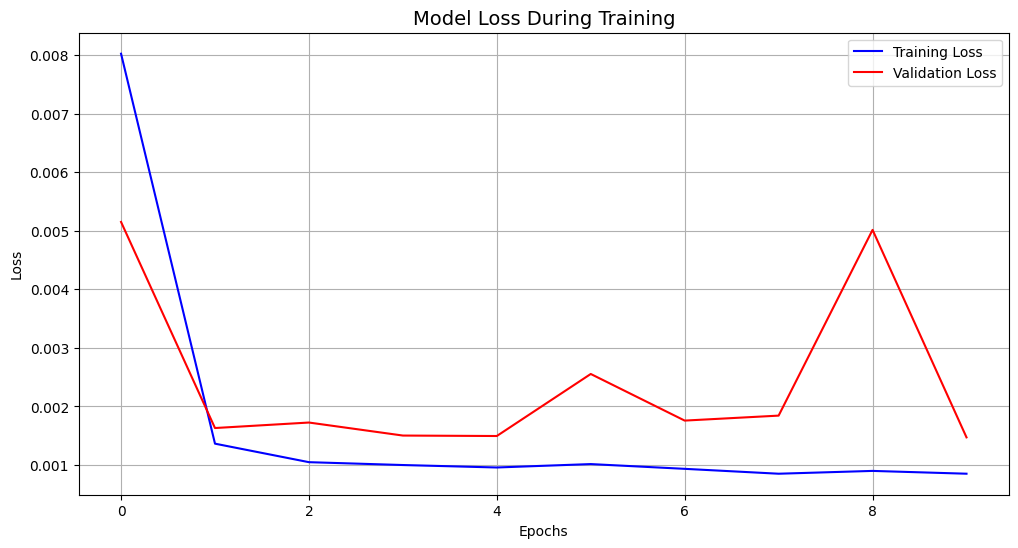

In [24]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

# Title and labels
plt.title('Model Loss During Training', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

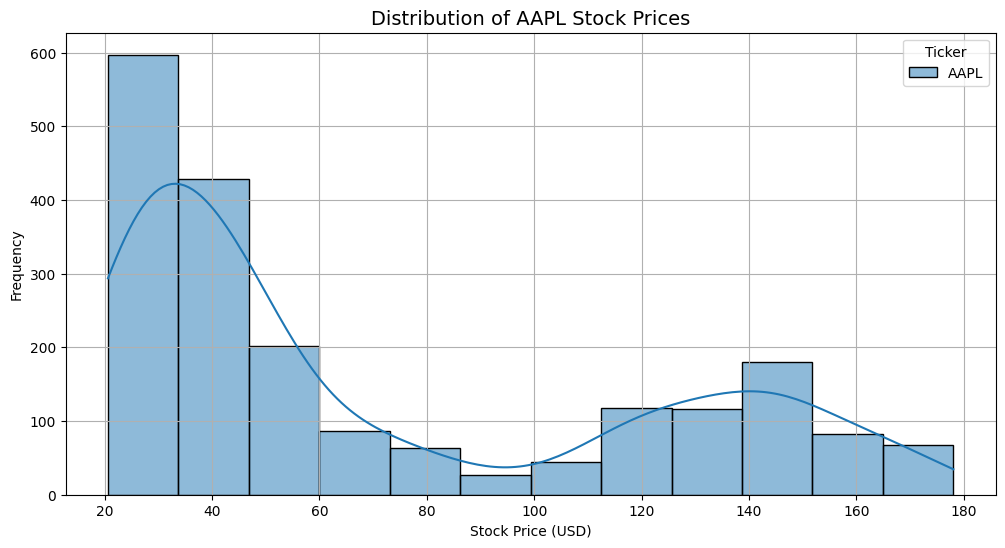

In [25]:
# Plotting the distribution of stock prices
plt.figure(figsize=(12, 6))
sns.histplot(stock_data['Close'], kde=True, color='purple')

# Title and labels
plt.title(f'Distribution of {stock_symbol} Stock Prices', fontsize=14)
plt.xlabel('Stock Price (USD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

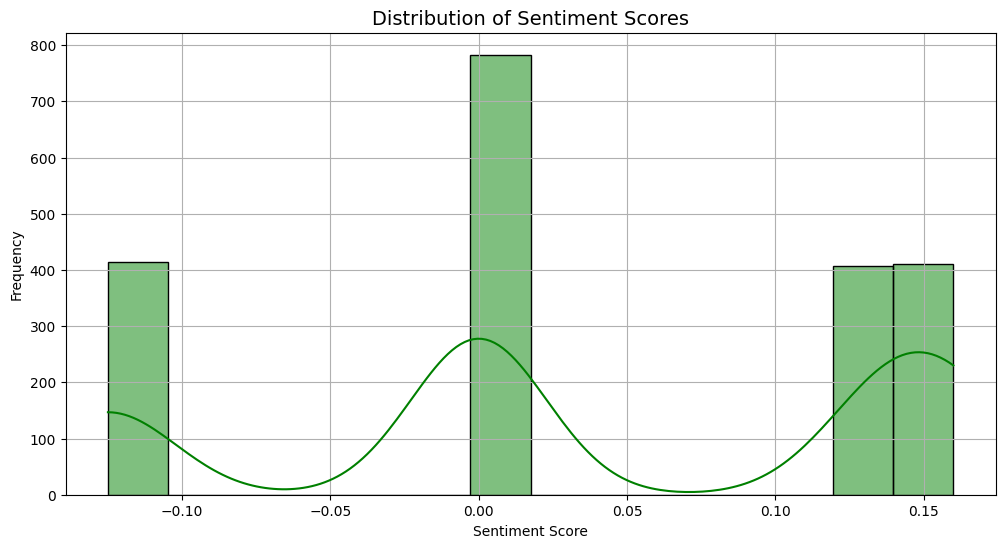

In [26]:
# Plotting the distribution of sentiment scores
plt.figure(figsize=(12, 6))
sns.histplot(stock_data['Sentiment'], kde=True, color='green')

# Title and labels
plt.title('Distribution of Sentiment Scores', fontsize=14)
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [27]:
# Measure the time taken for each epoch
import time

start_time = time.time()

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

end_time = time.time()

print(f"Total training time: {end_time - start_time:.2f} seconds")

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 7.3235e-04 - val_loss: 0.0018
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 7.0449e-04 - val_loss: 0.0018
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 7.5764e-04 - val_loss: 0.0025
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 7.6450e-04 - val_loss: 0.0016
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 6.8245e-04 - val_loss: 0.0039
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 6.8017e-04 - val_loss: 0.0013
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 7.0406e-04 - val_loss: 0.0017
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 8.1206e-04 - val_loss: 0.0012
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 8.3297e-04 - val_loss: 0.0012
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 7.4044e-04 - val_loss: 0.0014
Total training time: 22.33 seconds
